## **Assessing Passenger Satisfaction on Berlin Brandenburg Airport**
### **Author**: Rozh Basim Abdulah Ali.     

### **Project Description**

This project as part of master thesis, assess exploring Berlin Brandenburg Airport services quality's influnce on passengers satisfcation. The dataset source is primary which is obtained from passengers of Brandenburg airport. The project begins from exploring and processing raw data to develop main services quality dimensions. Then, exploratory data analysis are conducted to assess passengers demographic patterns and services indicators. Afterwarts, relational influence between passenger satsifcation and services' quality dimensions is explored in more details. Finaly, an estimating model is developed to predict passengers' satsifcation.

## 1. Import Libraries and Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/Responderss.csv')

## 2. Explore and Process Raw Dataset

In [ ]:
dataset.head()

,Gender,GroupAge,Ethnicity,EducationLevel,TravelFrequencyperyear,Purpose,FlightStatus,AirportMobileApp,T1,T2,...,E1,E2,E3,E4,A1,A2,A3,Ps1,Ps2,Ps3
0,Male,18-25,Caucasian,Higher Education,1 a year,Family Visit,Delayed,1,10,7,...,10,10,8,8,10,9,10,9,8,8
1,Male,18-25,Caucasian,Higher Education,1 a year,Family Visit,Delayed,1,10,8,...,10,10,8,8,10,8,9,9,8,8
2,Male,18-25,Caucasian,Higher Education,1 a year,Family Visit,Delayed,1,9,6,...,9,9,7,7,9,8,9,8,7,7
3,Male,26-35,Caucasian,Master,2-4 a year,Education,Delayed,1,8,8,...,7,7,7,7,6,7,6,7,7,6
4,Male,26-35,Black,Master,2-4 a year,Leisure,On Time,1,7,10,...,6,6,7,7,8,8,9,8,8,7


The dataset features demographic and social patterns as categorical values and features services' indicators as numeric values.

In [ ]:
dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  88 non-null     object
 1   GroupAge                88 non-null     object
 2   Ethnicity               88 non-null     object
 3   EducationLevel          88 non-null     object
 4   TravelFrequencyperyear  88 non-null     object
 5   Purpose                 88 non-null     object
 6   FlightStatus            88 non-null     object
 7   AirportMobileApp        88 non-null     int64 
 8   T1                      88 non-null     int64 
 9   T2                      88 non-null     int64 
 10  T3                      88 non-null     int64 
 11  T4                      88 non-null     int64 
 12  T5                      88 non-null     int64 
 13  Rel1                    88 non-null     int64 
 14  Rel2                    88 non-null     int64 
 15  Rel3    



**Indicators Description**
##### **Tangibility**
*   T1: Airport facilities and infrastructure cleanliness.
*   T2: Airport terminal design attractiveness such as climate control, natural lighting, and space availability.
*  T3: Airport wayfinding system for independent navigation ( e.g. signs, symbols, information display)
*   T4: Services and facilities availability to cover personal needs during the airport journey (e.g. Quiet waiting rooms, smoking places, children care places, washroom availability)
*   T5: Airport seat quality during waiting times.
##### **Reliability**
*   Rel1: Airport security procedures reliability and trustworthiness
*   Rel2: Airport leisure services and shops assessing passengers' well-being during their airport journey
*   Rel3: Avoidance of trust issues and uncomfortable stress during airport processing stages.
##### **Responsiveness**
*   Res1: Airport staff communication clarity during airport journey assistance
*   Res2: Airport staff customer care and passenger validation
*   Res3: Airport staff service personal politeness and positivity toward other passengers
*   Res4: Customer care of service facilities politeness and positivity (e.g. restaurants, shops)
##### **Assurance**
*   A1: Airport staff accessibility
*   A2: Airport staff expertise and knowledge when assisting the travel journey
*   A3: Airport staff availability in providing a sense of safety and psychological comfort during the airport journey
##### **Overall Satisfaction**
*   Ps1: Overall satisfaction with airport experience
*   Ps2: Airport capabilities in meeting expectations
*   Ps3: Recommending the airport to other travelers

In [ ]:
dataset.isnull().sum()
# dataset does not include null values.

,0
Gender,0
GroupAge,0
Ethnicity,0
EducationLevel,0
TravelFrequencyperyear,0
Purpose,0
FlightStatus,0
AirportMobileApp,0
T1,0
T2,0


In [ ]:
dataset.shape

(88, 31)

Integarte the services quality indicators to produce main variables:


*   Tangability
*   Reliability
*   Responsiveness
*   Empathy
*   Asurance
*   Overall Satisfaction



In [ ]:
def create_main_variables_from_indicators(dataset):
    # Create new columns by averaging indicators
    dataset['Tangability'] = dataset[['T1', 'T2', 'T3', 'T4', 'T5']].mean(axis=1)
    dataset['Reliability'] = dataset[['Rel1', 'Rel2', 'Rel3']].mean(axis=1)
    dataset['Responsiveness'] = dataset[['Res1', 'Res2', 'Res3', 'Res4', 'Res5']].mean(axis=1)
    dataset['Empathy'] = dataset[['E1', 'E2', 'E3', 'E4']].mean(axis=1)
    dataset['Assurance'] = dataset[['A1', 'A2', 'A3']].mean(axis=1)
    dataset['Overall_Satisfaction'] = dataset[['Ps1', 'Ps2', 'Ps3']].mean(axis=1)
    return dataset

# Apply the function to the dataset
dataset_with_derived_variables = create_main_variables_from_indicators(dataset.copy())
dataset= dataset_with_derived_variables

## 3. Exploratory Data Analysis

### 3.1 Demogrpahic patterns

Function to groupby services dimensions by demographic patterns

In [ ]:

# Define the six main variables of services quality and demogrpahic factors
variables = ['Tangability', 'Reliability', 'Responsiveness', 'Empathy', 'Assurance', 'Overall_Satisfaction']
demographic_factors= ['Gender', 'GroupAge','Ethnicity','EducationLevel','TravelFrequencyperyear','Purpose']

#function to group by services variables according to prefered demogrpahic factor
def demographic_perception(demographic_factor, variable):
  demographic_perspective = dataset.groupby(demographic_factor,)[variable].mean()
  return round(demographic_perspective,2)

# function to add the output to a mini dataset table
def variables_printing(demographic_variable):
  results = {}
  for variable in variables:
    results[variable] = demographic_perception(demographic_variable, variable)
  return pd.DataFrame(results)

#### 3.1.1 Gender

In [ ]:
variables_printing('Gender')
# Airport services quality from gender perspective

,Tangability,Reliability,Responsiveness,Empathy,Assurance,Overall_Satisfaction
Gender,,,,,,
Female,6.78,6.70,6.50,6.49,6.78,6.71
Male,6.68,7.02,6.86,6.76,7.11,6.74
Rather not to Say,6.70,7.43,7.12,7.00,6.97,7.10


#### 3.1.2 Group Age

In [ ]:
variables_printing('GroupAge')
# Airport services quality according to group ages


,Tangability,Reliability,Responsiveness,Empathy,Assurance,Overall_Satisfaction
GroupAge,,,,,,
18-25,7.16,7.31,7.35,7.49,7.62,7.51
26-35,6.70,6.90,6.70,6.55,6.98,6.67
36-45+,6.33,6.64,6.22,6.09,6.28,6.21


#### 3.1.3 Ethnicity

In [ ]:
variables_printing('Ethnicity')
# Airport services quality according to different ethnics

,Tangability,Reliability,Responsiveness,Empathy,Assurance,Overall_Satisfaction
Ethnicity,,,,,,
Black,6.75,7.12,7.01,6.21,6.76,6.63
Caucasian,6.80,7.29,6.97,7.30,7.61,7.44
Hispanic,6.65,6.55,6.43,6.36,6.49,6.25


#### 3.1.4 Education Level

In [ ]:
variables_printing('EducationLevel')
# Airport services quality according to different level of education

,Tangability,Reliability,Responsiveness,Empathy,Assurance,Overall_Satisfaction
EducationLevel,,,,,,
Bachelor,6.90,6.76,7.00,6.92,7.15,6.97
Doctoral,5.98,6.26,5.57,5.46,5.80,5.63
Higher Education,7.34,7.73,7.22,7.51,7.59,7.47
Master,6.63,7.11,6.98,6.72,7.17,6.90


#### 3.1.5 Travel Frequency Per Year

In [ ]:
variables_printing('TravelFrequencyperyear')
# Airport Services quality according to different level of travel frequency

,Tangability,Reliability,Responsiveness,Empathy,Assurance,Overall_Satisfaction
TravelFrequencyperyear,,,,,,
1 a year,7.38,7.35,7.48,7.39,7.62,7.50
2-4 a year,6.99,7.32,6.76,6.52,6.91,6.99
5+ a Year,5.93,6.22,6.16,6.31,6.51,5.98


#### 3.1.6 Traveling Purpose

In [ ]:
variables_printing('Purpose')
# Traveling purpose influnce on airport services quality perceptions

,Tangability,Reliability,Responsiveness,Empathy,Assurance,Overall_Satisfaction
Purpose,,,,,,
Business,5.80,6.68,6.11,5.97,6.56,6.20
Education,6.33,6.81,6.53,6.52,6.61,6.28
Family Visit,7.47,7.35,7.10,6.94,7.21,7.18
Leisure,6.88,6.78,7.00,7.09,7.19,7.05


### 3.2 Indicators of Services Quality

In [ ]:
indicators = dataset[['T1', 'T2', 'T3', 'T4', 'T5', 'Rel1', 'Rel2', 'Rel3', 'Res1', 'Res2',
       'Res3', 'Res4', 'Res5', 'E1', 'E2', 'E3', 'E4', 'A1', 'A2', 'A3', 'Ps1',
       'Ps2', 'Ps3']]
indicators.describe()

,T1,T2,T3,T4,T5,Rel1,Rel2,Rel3,Res1,Res2,...,E1,E2,E3,E4,A1,A2,A3,Ps1,Ps2,Ps3
count,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,...,88.00000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000
mean,7.852273,6.954545,6.681818,6.068182,6.068182,7.477273,6.318182,7.022727,7.090909,7.045455,...,6.75000,6.659091,6.613636,6.704545,6.818182,7.147727,6.920455,7.159091,6.761364,6.397727
std,1.169928,1.596757,2.141787,1.969862,2.016002,1.477628,1.657761,1.508423,1.885433,1.413474,...,1.59921,1.405133,1.334182,1.547405,1.771716,1.236790,1.288513,1.445456,1.546180,1.692035
min,5.000000,3.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,...,3.00000,4.000000,4.000000,3.000000,3.000000,4.000000,5.000000,3.000000,2.000000,2.000000
25%,7.000000,6.000000,5.750000,5.000000,5.000000,7.000000,5.000000,6.000000,6.000000,6.000000,...,6.00000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,5.000000
50%,8.000000,7.000000,7.000000,6.000000,6.000000,8.000000,7.000000,7.000000,7.000000,7.000000,...,7.00000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,6.000000
75%,9.000000,8.000000,8.000000,7.000000,8.000000,8.000000,8.000000,8.000000,9.000000,8.000000,...,8.00000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,7.250000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,9.000000,10.000000,10.000000,10.000000,...,10.00000,10.000000,9.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


#### 3.2.1 Tangability Indicators

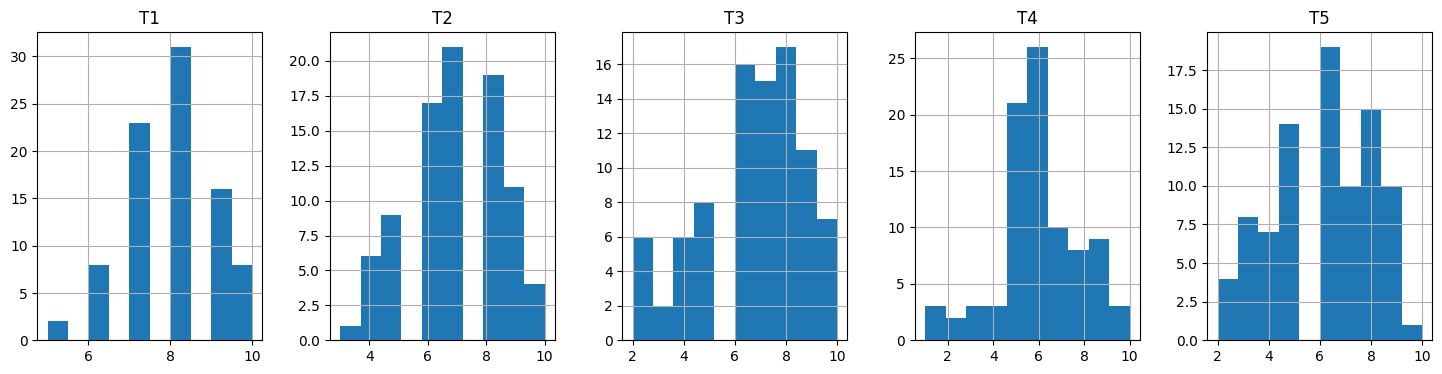

In [ ]:
indicators[['T1','T2','T3', 'T4', 'T5']].hist(figsize=(18,4),layout = (1,5), bins= 10)
plt.show()
# frequency score of responders for each tangability features.

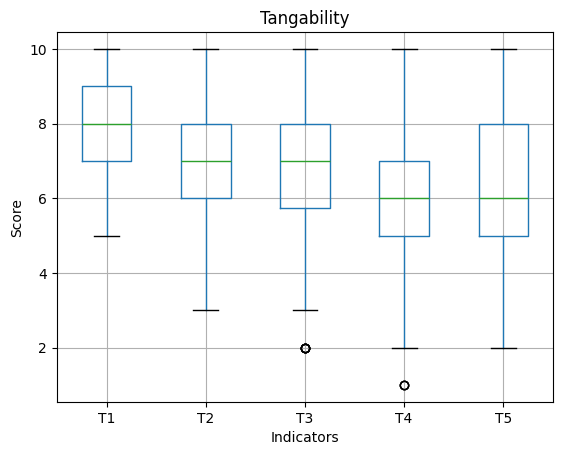

In [ ]:
indicators[['T1','T2','T3', 'T4', 'T5']].boxplot()
plt.title('Tangability')
plt.xlabel('Indicators')
plt.ylabel('Score')
plt.show()


#### 3.2.2 Reliability Indicators

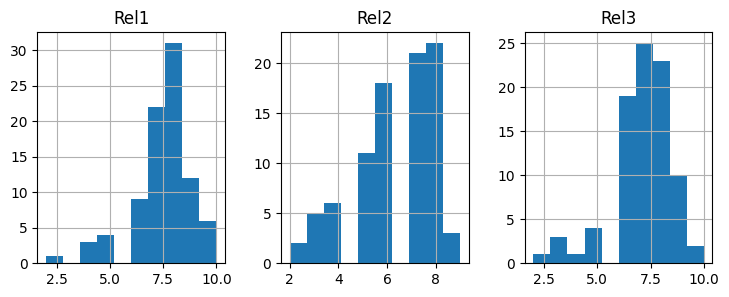

In [ ]:
indicators[['Rel1', 'Rel2', 'Rel3']].hist(figsize=(15,3),layout = (1,5), bins= 10)
plt.show()

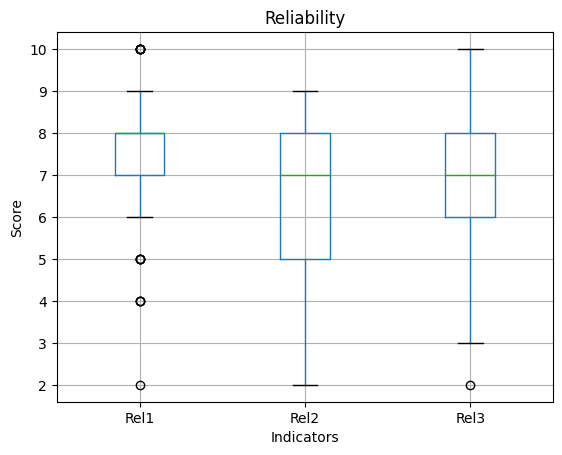

In [ ]:
indicators[['Rel1', 'Rel2', 'Rel3']].boxplot()
plt.title('Reliability')
plt.xlabel('Indicators')
plt.ylabel('Score')
plt.show()

#### 3.2.3 Responsiveness Indicators

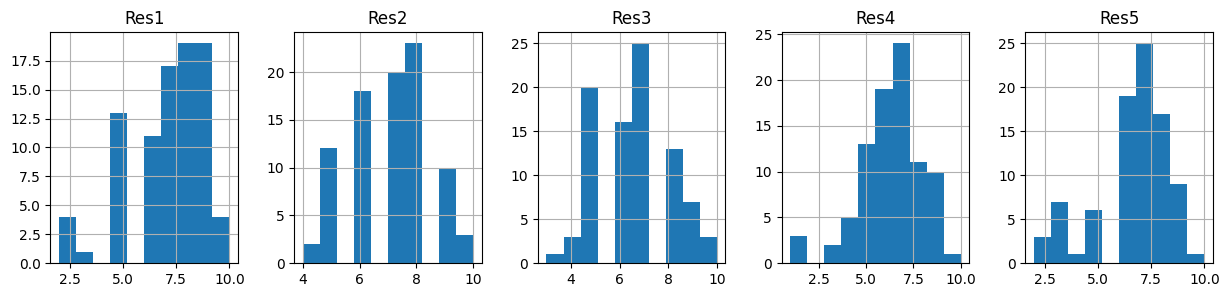

In [ ]:
indicators[['Res1', 'Res2', 'Res3', 'Res4', 'Res5']].hist(figsize=(15,3),layout = (1,5), bins= 10)
plt.show()

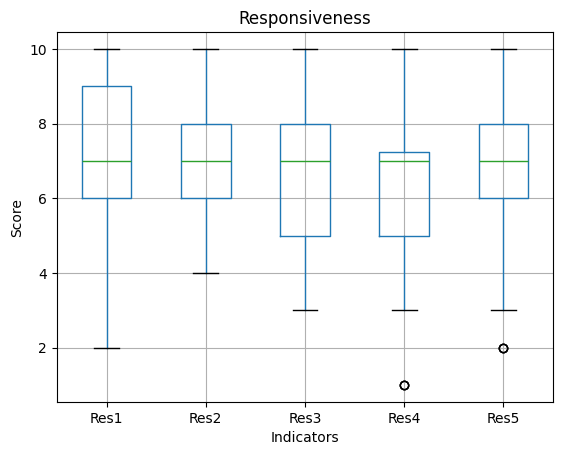

In [ ]:
indicators[['Res1', 'Res2', 'Res3', 'Res4', 'Res5']].boxplot()
plt.title('Responsiveness')
plt.xlabel('Indicators')
plt.ylabel('Score')
plt.show()

#### 3.2.4 Empathy Indicators

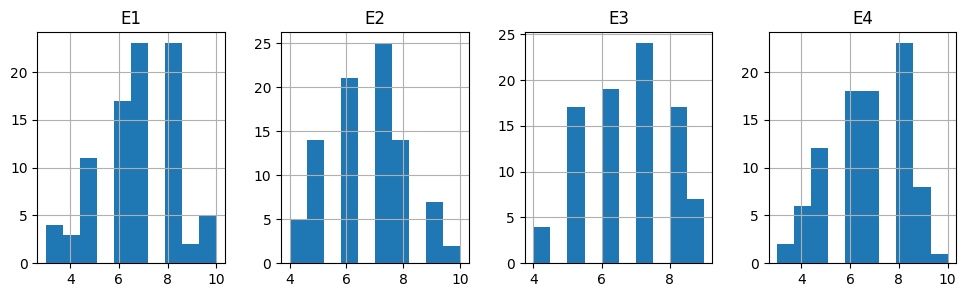

In [ ]:
indicators[['E1', 'E2', 'E3', 'E4']].hist(figsize=(15,3),layout = (1,5), bins= 10)
plt.show()

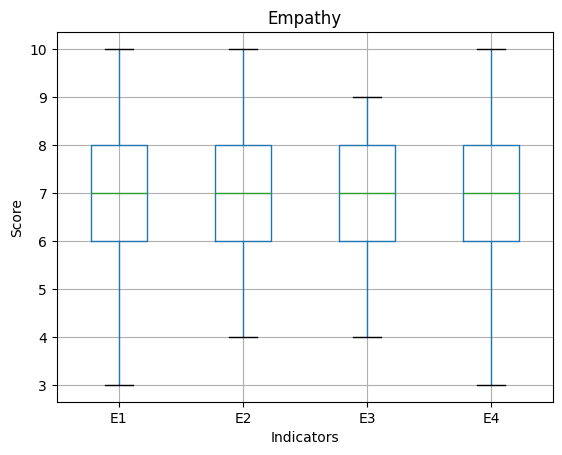

In [ ]:
indicators[['E1', 'E2', 'E3', 'E4']].boxplot()
plt.title('Empathy')
plt.xlabel('Indicators')
plt.ylabel('Score')
plt.show()

#### 3.2.5 Assurance  Indicators

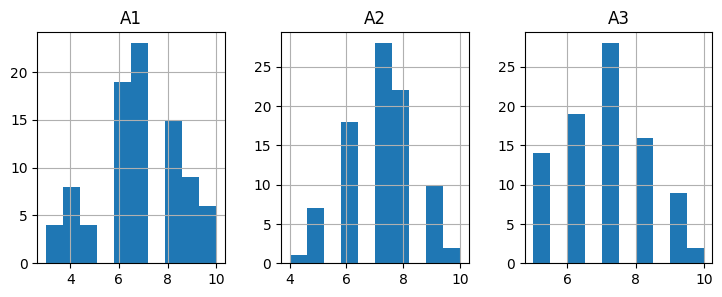

In [ ]:
indicators[['A1', 'A2', 'A3']].hist(figsize=(15,3),layout = (1,5), bins= 10)
plt.show()

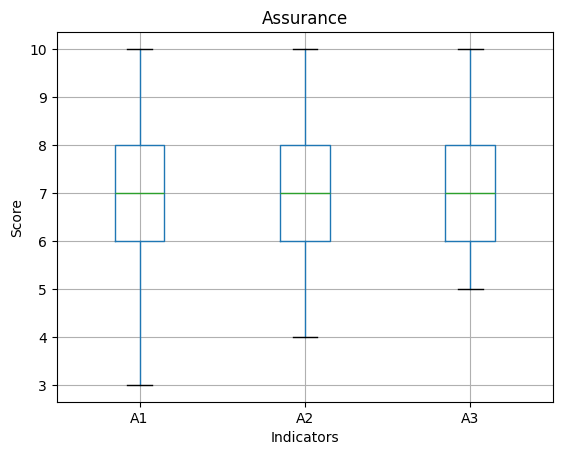

In [ ]:
indicators[['A1','A2', 'A3']].boxplot()
plt.title('Assurance')
plt.xlabel('Indicators')
plt.ylabel('Score')
plt.show()

#### 3.2.6 Overall Satisfaction  Indicators

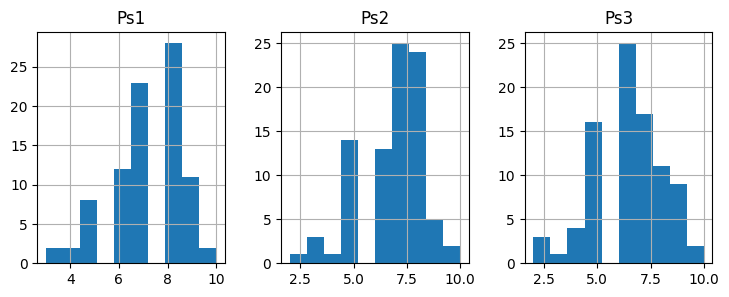

In [ ]:
indicators[['Ps1', 'Ps2', 'Ps3']].hist(figsize=(15,3),layout = (1,5), bins= 10)
plt.show()

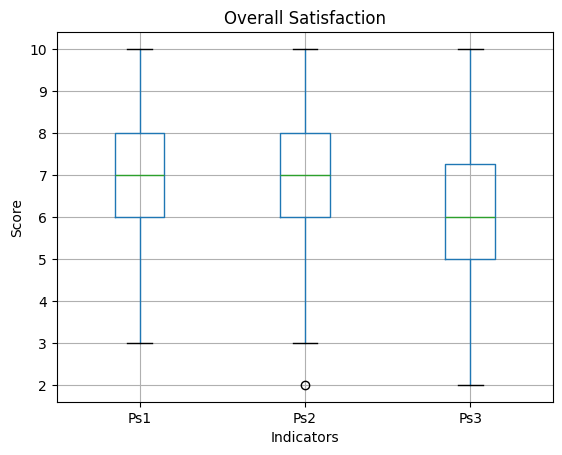

In [ ]:
indicators[['Ps1','Ps2', 'Ps3']].boxplot()
plt.title('Overall Satisfaction')
plt.xlabel('Indicators')
plt.ylabel('Score')
plt.show()

### 3.3 Services quality and overall satisfaction

In [ ]:
dataset.columns

Index(['Gender', 'GroupAge', 'Ethnicity', 'EducationLevel',
       'TravelFrequencyperyear', 'Purpose', 'FlightStatus', 'AirportMobileApp',
       'T1', 'T2', 'T3', 'T4', 'T5', 'Rel1', 'Rel2', 'Rel3', 'Res1', 'Res2',
       'Res3', 'Res4', 'Res5', 'E1', 'E2', 'E3', 'E4', 'A1', 'A2', 'A3', 'Ps1',
       'Ps2', 'Ps3', 'Tangability', 'Reliability', 'Responsiveness', 'Empathy',
       'Assurance', 'Overall_Satisfaction'],
      dtype='object')

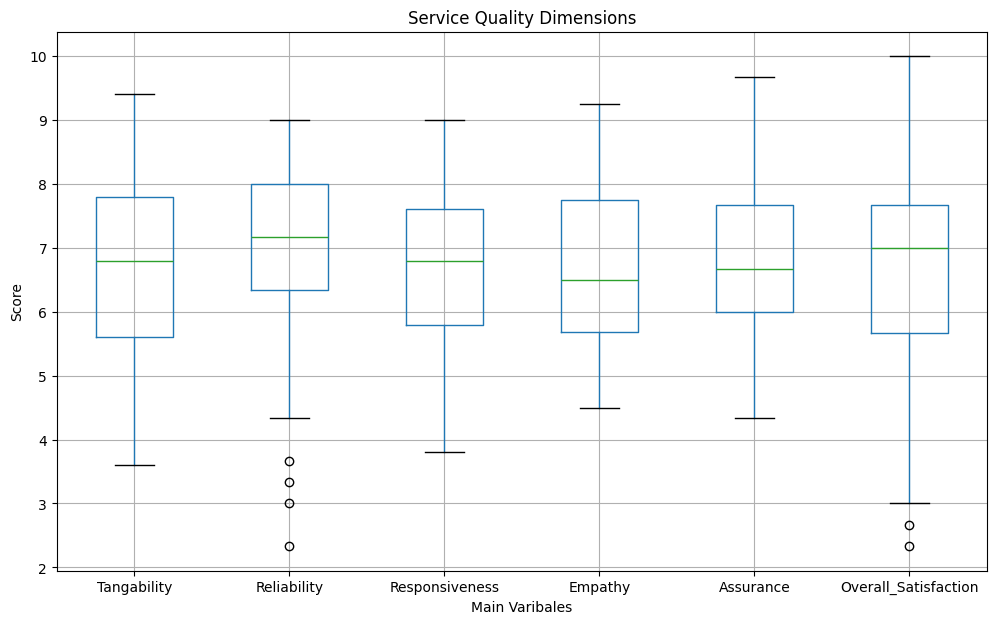

In [ ]:
plt.figure(figsize=(12,7))
dataset[['Tangability', 'Reliability', 'Responsiveness', 'Empathy',
       'Assurance', 'Overall_Satisfaction']].boxplot()
plt.title('Service Quality Dimensions')
plt.xlabel('Main Varibales')
plt.ylabel('Score')
plt.show()

All services variables recieve sufficint expression by airport passengers.

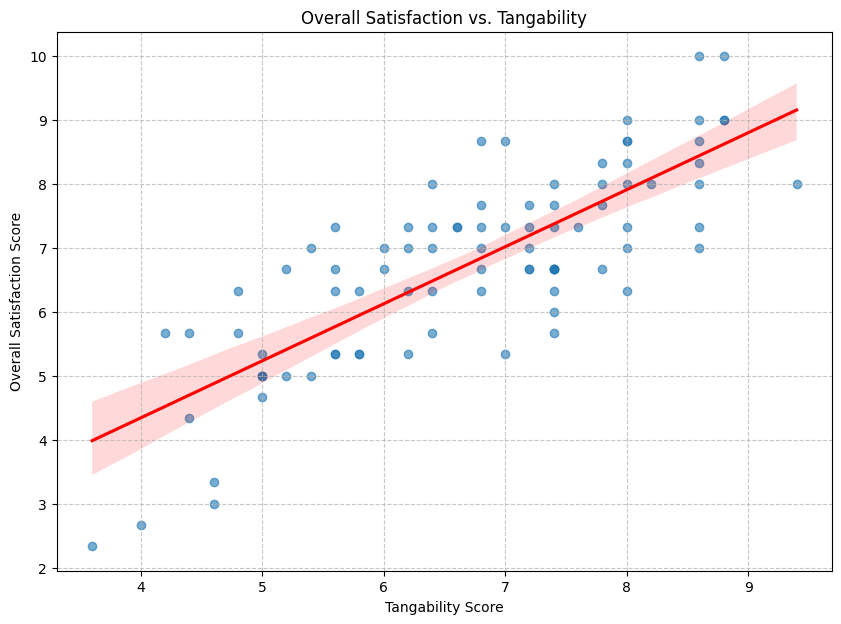

In [ ]:
plt.figure(figsize=(10, 7))
sns.regplot(x='Tangability', y='Overall_Satisfaction', data=dataset, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Overall Satisfaction vs. Tangability')
plt.xlabel('Tangability Score')
plt.ylabel('Overall Satisfaction Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

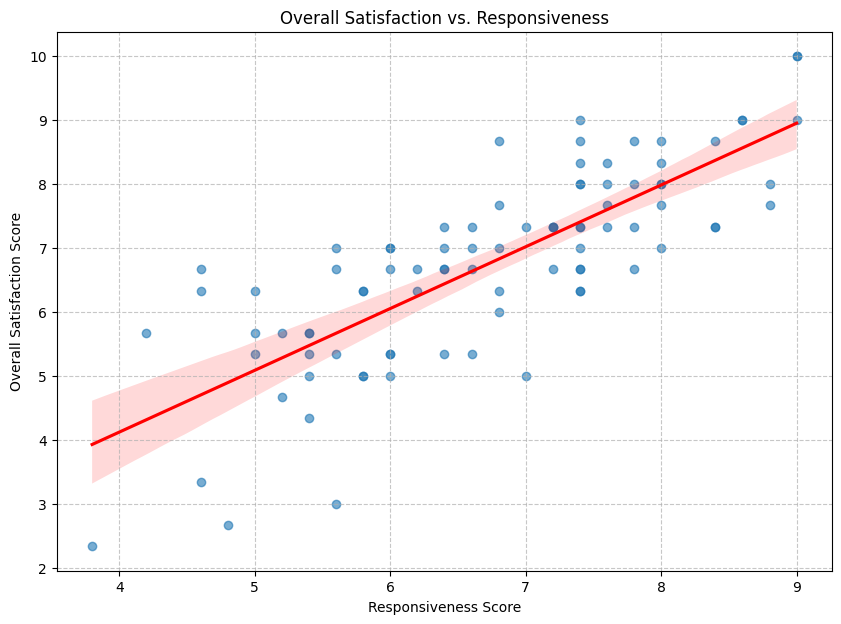

In [ ]:
plt.figure(figsize=(10, 7))
sns.regplot(x='Responsiveness', y='Overall_Satisfaction', data=dataset, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Overall Satisfaction vs. Responsiveness')
plt.xlabel('Responsiveness Score')
plt.ylabel('Overall Satisfaction Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

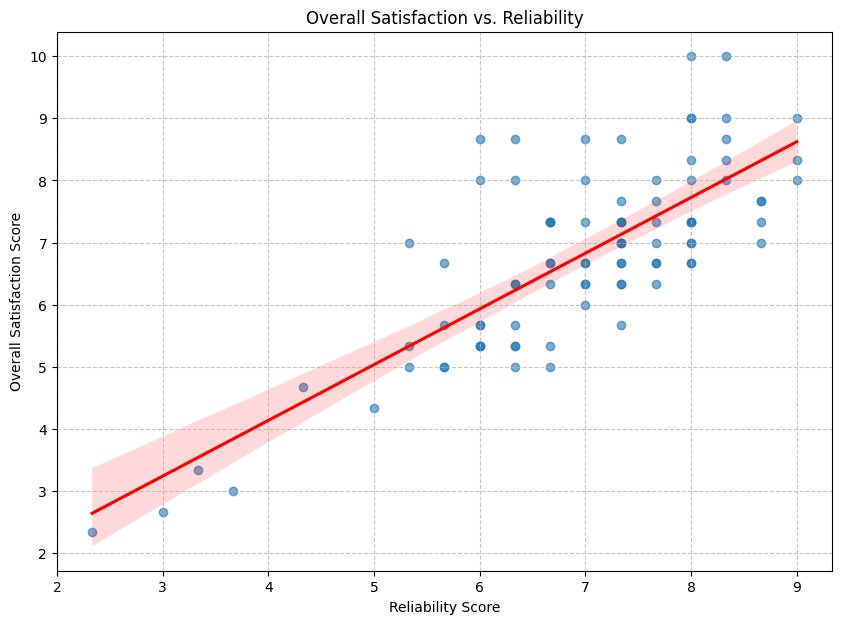

In [ ]:
plt.figure(figsize=(10, 7))
sns.regplot(x='Reliability', y='Overall_Satisfaction', data=dataset, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Overall Satisfaction vs. Reliability')
plt.xlabel('Reliability Score')
plt.ylabel('Overall Satisfaction Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

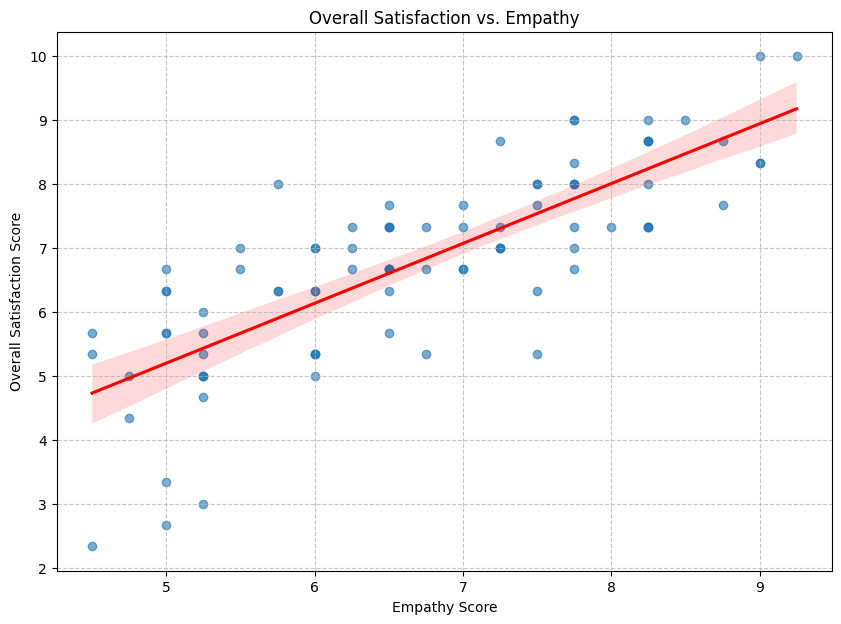

In [ ]:
plt.figure(figsize=(10, 7))
sns.regplot(x='Empathy', y='Overall_Satisfaction', data=dataset, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Overall Satisfaction vs. Empathy')
plt.xlabel('Empathy Score')
plt.ylabel('Overall Satisfaction Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

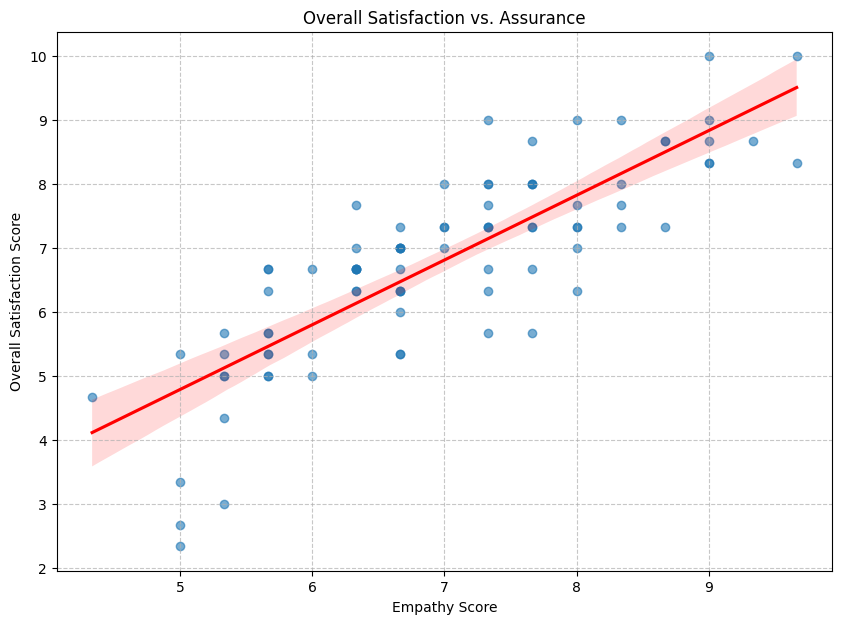

In [ ]:
plt.figure(figsize=(10, 7))
sns.regplot(x='Assurance', y='Overall_Satisfaction', data=dataset, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Overall Satisfaction vs. Assurance')
plt.xlabel('Empathy Score')
plt.ylabel('Overall Satisfaction Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Relational pattern is linear between each of services quality dimensions and overall satisfaction, meaning the increae of each services quality leads to increase passenger satisfaction.

## 4. Estimating Passenger Satisfaction

### 4.1 Data Preprocessing

In [ ]:
dataset.head(1)

,Gender,GroupAge,Ethnicity,EducationLevel,TravelFrequencyperyear,Purpose,FlightStatus,AirportMobileApp,T1,T2,...,A3,Ps1,Ps2,Ps3,Tangability,Reliability,Responsiveness,Empathy,Assurance,Overall_Satisfaction
0,Male,18-25,Caucasian,Higher Education,1 a year,Family Visit,Delayed,1,10,7,...,10,9,8,8,8.0,8.0,7.4,9.0,9.666667,8.333333


In [ ]:
dataset.columns


Index(['Gender', 'GroupAge', 'Ethnicity', 'EducationLevel',
       'TravelFrequencyperyear', 'Purpose', 'FlightStatus', 'AirportMobileApp',
       'T1', 'T2', 'T3', 'T4', 'T5', 'Rel1', 'Rel2', 'Rel3', 'Res1', 'Res2',
       'Res3', 'Res4', 'Res5', 'E1', 'E2', 'E3', 'E4', 'A1', 'A2', 'A3', 'Ps1',
       'Ps2', 'Ps3', 'Tangability', 'Reliability', 'Responsiveness', 'Empathy',
       'Assurance', 'Overall_Satisfaction'],
      dtype='object')

In [ ]:
variables_of_interest = ['Gender', 'GroupAge', 'Ethnicity', 'EducationLevel',
       'TravelFrequencyperyear', 'Purpose', 'FlightStatus', 'AirportMobileApp',
      'Tangability', 'Reliability', 'Responsiveness', 'Empathy',
       'Assurance', 'Overall_Satisfaction']
data_processing = dataset[variables_of_interest]


Indicators are excluded as they already been used to develop main varibales .

In [ ]:
data_processing.describe(include = 'all')

,Gender,GroupAge,Ethnicity,EducationLevel,TravelFrequencyperyear,Purpose,FlightStatus,AirportMobileApp,Tangability,Reliability,Responsiveness,Empathy,Assurance,Overall_Satisfaction
count,88,88,88,88,88,88,88,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000
unique,3,3,3,4,3,4,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Male,26-35,Hispanic,Bachelor,2-4 a year,Family Visit,On Time,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,43,40,38,29,33,28,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.227273,6.725000,6.939394,6.745455,6.681818,6.962121,6.772727
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.421472,1.341919,1.306771,1.226424,1.266686,1.221803,1.498868
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3.600000,2.333333,3.800000,4.500000,4.333333,2.333333
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,5.600000,6.333333,5.800000,5.687500,6.000000,5.666667
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,6.800000,7.166667,6.800000,6.500000,6.666667,7.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,7.800000,8.000000,7.600000,7.750000,7.666667,7.666667


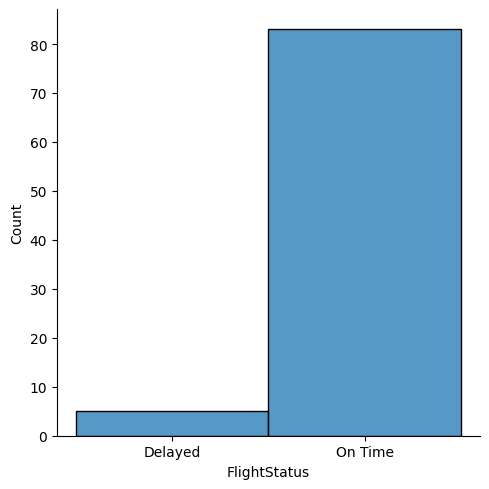

In [ ]:
sns.displot(dataset['FlightStatus'])


Very few responders encountered flight delay. Therfore, to avoid noise in the model, the flight status column would be droped


In [ ]:
data_processing= data_processing.drop(['FlightStatus'],axis = 1)


In [ ]:
data_processing= data_processing.drop(['AirportMobileApp'],axis = 1)


The Airport Mobile App contrbution is less importatnt compare to other variables. Therefore, it is droped to ensure main variables of interest are remained.

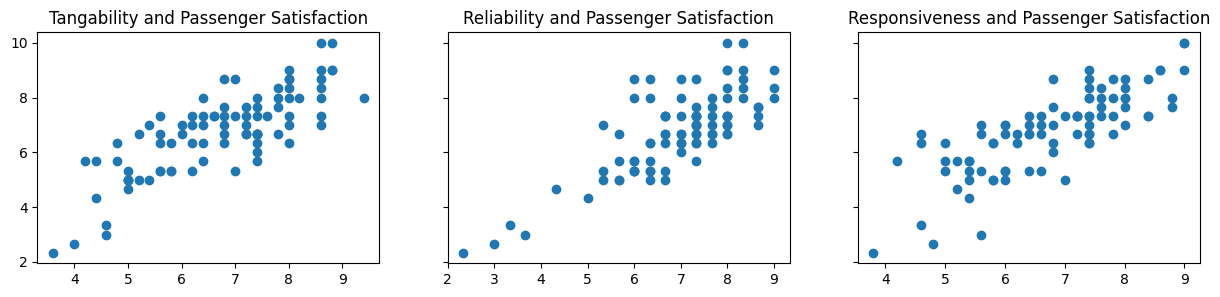

In [ ]:
f, (ax1, ax2, ax3) = plt.subplots(1,3, sharey= True, figsize= (15,3))
ax1.scatter(data_processing['Tangability'], data_processing['Overall_Satisfaction'])
ax1.set_title('Tangability and Passenger Satisfaction')
ax2.scatter(data_processing['Reliability'], data_processing['Overall_Satisfaction'])
ax2.set_title('Reliability and Passenger Satisfaction')
ax3.scatter(data_processing['Responsiveness'], data_processing['Overall_Satisfaction'])
ax3.set_title('Responsiveness and Passenger Satisfaction')
plt.show()

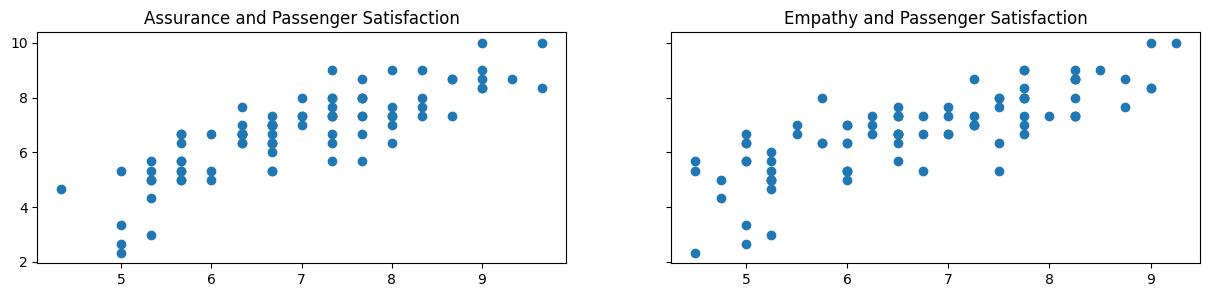

In [ ]:
f, (ax4, ax5) = plt.subplots(1,2, sharey= True, figsize= (15,3))
ax4.scatter(data_processing['Assurance'], data_processing['Overall_Satisfaction'])
ax4.set_title('Assurance and Passenger Satisfaction')
ax5.scatter(data_processing['Empathy'], data_processing['Overall_Satisfaction'])
ax5.set_title('Empathy and Passenger Satisfaction')
plt.show()

In [ ]:
data_processing.columns.values

array(['Gender', 'GroupAge', 'Ethnicity', 'EducationLevel',
       'TravelFrequencyperyear', 'Purpose', 'Tangability', 'Reliability',
       'Responsiveness', 'Empathy', 'Assurance', 'Overall_Satisfaction'],
      dtype=object)

Process Categorical Data

In [ ]:
categorical_data_processing = pd.get_dummies(data_processing, drop_first=True)

In [ ]:
categorical_data_processing.head()

,Tangability,Reliability,Responsiveness,Empathy,Assurance,Overall_Satisfaction,Gender_Male,Gender_Rather not to Say,GroupAge_26-35,GroupAge_36-45+,Ethnicity_Caucasian,Ethnicity_Hispanic,EducationLevel_Doctoral,EducationLevel_Higher Education,EducationLevel_Master,TravelFrequencyperyear_2-4 a year,TravelFrequencyperyear_5+ a Year,Purpose_Education,Purpose_Family Visit,Purpose_Leisure
0,8.0,8.000000,7.4,9.0,9.666667,8.333333,True,False,False,False,True,False,False,True,False,False,False,False,True,False
1,8.6,9.000000,8.0,9.0,9.000000,8.333333,True,False,False,False,True,False,False,True,False,False,False,False,True,False
2,7.0,7.000000,6.4,8.0,8.666667,7.333333,True,False,False,False,True,False,False,True,False,False,False,False,True,False
3,7.2,7.333333,6.2,7.0,6.333333,6.666667,True,False,True,False,True,False,False,False,True,True,False,True,False,False
4,7.4,7.333333,8.8,6.5,8.333333,7.666667,True,False,True,False,False,False,False,False,True,True,False,False,False,True


In [ ]:
categorical_data_processing.columns.values

array(['Tangability', 'Reliability', 'Responsiveness', 'Empathy',
       'Assurance', 'Overall_Satisfaction', 'Gender_Male',
       'Gender_Rather not to Say', 'GroupAge_26-35', 'GroupAge_36-45+',
       'Ethnicity_Caucasian', 'Ethnicity_Hispanic',
       'EducationLevel_Doctoral', 'EducationLevel_Higher Education',
       'EducationLevel_Master', 'TravelFrequencyperyear_2-4 a year',
       'TravelFrequencyperyear_5+ a Year', 'Purpose_Education',
       'Purpose_Family Visit', 'Purpose_Leisure'], dtype=object)

In [ ]:
# columns re arranging
columns = ['Gender_Male', 'Gender_Rather not to Say', 'GroupAge_26-35', 'GroupAge_36-45+',
       'Ethnicity_Caucasian', 'Ethnicity_Hispanic',
       'EducationLevel_Doctoral', 'EducationLevel_Higher Education',
       'EducationLevel_Master', 'TravelFrequencyperyear_2-4 a year',
       'TravelFrequencyperyear_5+ a Year', 'Purpose_Education',
       'Purpose_Family Visit', 'Purpose_Leisure', 'Tangability', 'Reliability', 'Responsiveness', 'Empathy',
       'Assurance', 'Overall_Satisfaction']
data_cleaned = categorical_data_processing[columns]

In [ ]:
data_cleaned.head()

,Gender_Male,Gender_Rather not to Say,GroupAge_26-35,GroupAge_36-45+,Ethnicity_Caucasian,Ethnicity_Hispanic,EducationLevel_Doctoral,EducationLevel_Higher Education,EducationLevel_Master,TravelFrequencyperyear_2-4 a year,TravelFrequencyperyear_5+ a Year,Purpose_Education,Purpose_Family Visit,Purpose_Leisure,Tangability,Reliability,Responsiveness,Empathy,Assurance,Overall_Satisfaction
0,True,False,False,False,True,False,False,True,False,False,False,False,True,False,8.0,8.000000,7.4,9.0,9.666667,8.333333
1,True,False,False,False,True,False,False,True,False,False,False,False,True,False,8.6,9.000000,8.0,9.0,9.000000,8.333333
2,True,False,False,False,True,False,False,True,False,False,False,False,True,False,7.0,7.000000,6.4,8.0,8.666667,7.333333
3,True,False,True,False,True,False,False,False,True,True,False,True,False,False,7.2,7.333333,6.2,7.0,6.333333,6.666667
4,True,False,True,False,False,False,False,False,True,True,False,False,False,True,7.4,7.333333,8.8,6.5,8.333333,7.666667


In [ ]:
dataset= dataset_with_derived_variables
dataset.head()

,Gender,GroupAge,Ethnicity,EducationLevel,TravelFrequencyperyear,Purpose,FlightStatus,AirportMobileApp,T1,T2,...,A3,Ps1,Ps2,Ps3,Tangability,Reliability,Responsiveness,Empathy,Assurance,Overall_Satisfaction
0,Male,18-25,Caucasian,Higher Education,1 a year,Family Visit,Delayed,1,10,7,...,10,9,8,8,8.0,8.000000,7.4,9.0,9.666667,8.333333
1,Male,18-25,Caucasian,Higher Education,1 a year,Family Visit,Delayed,1,10,8,...,9,9,8,8,8.6,9.000000,8.0,9.0,9.000000,8.333333
2,Male,18-25,Caucasian,Higher Education,1 a year,Family Visit,Delayed,1,9,6,...,9,8,7,7,7.0,7.000000,6.4,8.0,8.666667,7.333333
3,Male,26-35,Caucasian,Master,2-4 a year,Education,Delayed,1,8,8,...,6,7,7,6,7.2,7.333333,6.2,7.0,6.333333,6.666667
4,Male,26-35,Black,Master,2-4 a year,Leisure,On Time,1,7,10,...,9,8,8,7,7.4,7.333333,8.8,6.5,8.333333,7.666667


### 4.2 Models to Estimate Passenger Satisfaction

In [ ]:
# Define target variable for estimation and influencial inputs variables
targets = data_cleaned['Overall_Satisfaction']
inputs = data_cleaned.drop(['Overall_Satisfaction'], axis = 1)
from sklearn.preprocessing import StandardScaler

# scale data
scaler = StandardScaler()
scaler.fit(inputs)
scaled_inputs = scaler.transform(inputs)

# Train Test Split
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(scaled_inputs, targets, test_size = 0.2, random_state = 365)


### 4.2.1. Decision Tree Regression

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# 1. Initialize the base model by calling the function
decisiontree = DecisionTreeRegressor(random_state=42)

# 2. Define a param grid
param_grid = {
    'max_depth': [None, 5, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']
}

# 3. Set up the Grid Search
grid_search = GridSearchCV(
    estimator=decisiontree,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# 4. Fit the grid search to the data
grid_search.fit(x_train, y_train)


decision_tree_tunning = grid_search.best_estimator_

y_pred_decisiontree = decision_tree_tunning.predict(x_test)
mse_decisiontree = mean_squared_error(y_test, y_pred_decisiontree)
r2_decisiontree = r2_score(y_test, y_pred_decisiontree)

print(f"Decision Tree Mean Squared Error: {mse_decisiontree}")
print(f"Decision Tree R-squared: {r2_decisiontree}")

# predictions = best_decisiontree.predict(x_test)

Fitting 5 folds for each of 864 candidates, totalling 4320 fits
Decision Tree Mean Squared Error: 0.5679012345679012
Decision Tree R-squared: 0.7245508982035929


### 4.2.2 Gradient Boosting Regression

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
reg= GradientBoostingRegressor(random_state=42)

reg.fit(x_train, y_train)
y_pred_gradientboosting = reg.predict(x_test)
reg.score(x_test, y_test)
mse_gradientboosting = mean_squared_error(y_test, y_pred_gradientboosting)
r2_gradientboosting = r2_score(y_test, y_pred_gradientboosting)

print(f"Gradient Boosting Mean Squared Error: {mse_gradientboosting}")
print(f"Gradient Boosting R-squared: {r2_gradientboosting}")


Gradient Boosting Mean Squared Error: 0.3698908612818865
Gradient Boosting R-squared: 0.8205918577016


### **Models Discussion**

Decision Tree Regression model achieves less accuracy in comparison to Gradient Boosting Regression. The Gradient Boosting regression achieves 82% accuracy to predict passengers satisfaction following each passengers' demogprahic prefrences and their perceptions' on airport services quality.